
# Deep Learning with Python

Welcome to the **Deep Learning** course! This course is designed to give you hands-on experience with the foundational concepts and advanced techniques in deep learning. You will explore:

- Artificial Neural Networks and Gradient Descent
- Convolutional Neural Networks (CNNs) for Computer Vision
- Recurrent Neural Networks (RNNs) for Text Prediction
- Diffusion Transformers for Image Generation

Throughout the course, you'll engage in projects to solidify your understanding and gain practical skills in implementing deep learning algorithms.  

Instructor: Dr. Adrien Dorise  
Contact: adrien.dorise@hotmail.com  

---


## Part1: Perceptron with Gradient Descent
In this project, you will build a perceptron from scratch and gain a deeper understanding of how gradient descent works in optimizing models. The tasks you will complete include:

1. **Import and Understand a Dataset**: Learn how to load, preprocess, and explore a dataset to prepare it for training.
2. **Implement a Perceptron from Scratch**: Code the perceptron algorithm using only fundamental Python and NumPy.
3. **Implement Gradient Descent**: Incorporate gradient descent to optimize the perceptron's weights.
4. **Evaluate the Model on Simple Logical Functions**: Test your perceptron on logical functions like AND, OR, and XOR to understand their capabilities and limitations.
5. **Evaluate the Model on a Real-World Dataset**: Apply your perceptron to a simple real-world dataset and assess its performance.

By the end of this project, you'll have a solid understanding of how perceptrons work and how gradient descent improves their performance. This foundational knowledge will prepare you for more advanced neural network architectures in subsequent projects.

---

## Dataset

This exercise will start by importing a simple dataset based on AND, OR and XOR logical functions.  
These functions consist of binary inputs and outputs, used for training and testing basic neural network models. 

**AND Dataset**  
The AND operation returns 1 if both inputs are 1, and 0 otherwise.

| Input 1 | Input 2 | Output (AND) |
|---------|---------|--------------|
| 0       | 0       | 0            |
| 0       | 1       | 0            |
| 1       | 0       | 0            |
| 1       | 1       | 1            |

**OR Dataset**  
The OR operation returns 1 if at least one input is 1.

| Input 1 | Input 2 | Output (OR) |
|---------|---------|-------------|
| 0       | 0       | 0           |
| 0       | 1       | 1           |
| 1       | 0       | 1           |
| 1       | 1       | 1           |

**XOR Dataset**  
The XOR operation returns 1 if the inputs are different, and 0 if they are the same.

| Input 1 | Input 2 | Output (XOR) |
|---------|---------|--------------|
| 0       | 0       | 0            |
| 0       | 1       | 1            |
| 1       | 0       | 1            |
| 1       | 1       | 0            |



In [8]:
# Import relevant packages

import numpy as np 
import matplotlib.pyplot as plt
import pandas

# Create the dataset

## AND dataset
and_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
and_outputs = np.array([[0], [0], [0], [1]])

## OR dataset
or_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
or_outputs = np.array([[0], [1], [1], [1]])

## XOR dataset
xor_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_outputs = np.array([[0], [1], [1], [0]])


# Explore the dataset
for i in range(len(and_inputs)):
    print(f"{and_inputs[i]} -> {and_outputs[i]}")


[0 0] -> [0]
[0 1] -> [0]
[1 0] -> [0]
[1 1] -> [1]


## Create the Perceptron

<img src="../docs/perceptron.jpg" alt="Perceptron" width="500"/>  



You will now have to implement the perceptron from scratch!
It means recreating its function:  
$
\hat{y} = f(\sum_{i=1}^{n}(w_i x_i) + b) = f(w_1x_1 + w_2x_2 +...+w_nx_n +b)
$

It is done by:
 - Implementing the weighted sum
 - Implementing the activation function
 - Creating the perceptron
 - Defining the loss function
 - Implementing the optimisation with gradient descent
    - Weights update
    - Bias update


**Weighted sum**
- Complete the code below to create the weighted sum function.
- It has to take an input vector, a weight vector and a bias value as input. 
- Feel free to experiment with the dataset created before to be sure that your function is working as expected.


In [9]:
# TODO

weights = None
bias = None

def weighted_sum(x, weights, bias):
    # Produit scalaire entre les entrées et les poids, + le biais
    # Equivalent à : w1*x1 + w2*x2 + ... + wn*xn + b
    return np.dot(x, weights) + bias

**Activation function**
- Complete the code below to create the activation function
- You can choose whatever activation function you want. 
- Be careful, as the step function has no gradient.
- Sigmoid or ReLu functions seem to be a good fit!   
$
ReLU(x) = 
\begin{cases} 
	w, & \text{if } x > 0 \\
	0, & \text{if } x \leq 0
\end{cases}
$  
$
\sigma(x) = \frac{1}{1+e^{-x}}
$

In [ ]:
# TODO

def activation_function(x):
    # La sigmoid écrase n'importe quelle valeur entre 0 et 1
    # Permet d'interpréter la sortie comme une probabilité
    return 1 / (1 + np.exp(-x))

**Perceptron**
- Complete the code below to create the forward function of your percetron.
- feel free to test with the dummy data!

In [11]:
dummy_x = [1,2,3,4]
dummy_weights = [2,1,0,-1]
dummy_bias = 0.5

def predict(x, weights, bias):
    # Étape 1 : combinaison linéaire des entrées
    z = weighted_sum(x, weights, bias)
    # Étape 2 : on passe z dans la fonction d'activation pour obtenir une prédiction
    return activation_function(z)

print(f"weights = {dummy_weights}")
print(f"bias = {dummy_bias}")
print(f"inputs = {dummy_x}")
print(f"weighted sum = {weighted_sum(dummy_x, dummy_weights, dummy_bias)}")   
print(f"prediction = {predict(dummy_x, dummy_weights, dummy_bias)}")


weights = [2, 1, 0, -1]
bias = 0.5
inputs = [1, 2, 3, 4]
weighted sum = 0.5
prediction = 0.6224593312018546


**Loss function** 
- Complete the code below to create your custom loss function.
- You will have to make a function that calculates the loss of a single sample, and a function that takes a batch of samples as input
- The L2 loss is a good start:  
$
\mathcal{L}(\hat{y},y) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$


In [12]:
# TODO

def compute_loss_sample(prediction, target):
    # Erreur quadratique pour un seul exemple : (ŷ - y)²
    return (prediction - target) ** 2

def compute_loss_batch(predictions, targets):
    # Moyenne des erreurs quadratiques sur tous les exemples (MSE)
    return np.mean((predictions - targets) ** 2)

**Gradient**  
The gradient update is a formula of the form:  
$ \theta_i \leftarrow \theta_i - \alpha \nabla_{\theta_i} J(\theta_i) $

- Complete the code below to compute the gradient of the loss function $\nabla_{\theta_i} \mathcal{L}_{\theta_i}$ 
    - in regards to the weights
    - in regards to the bias
- You will have to return the gradient for each weight in your perceptron as a vector.
- **Be careful to include the derivative of your activation function!**
  - Create a function to compute the derivative in regards to the weighted some *z*.
- If you are lost, go back to part 1 of the course.
    - Get back to the slides 38->48

In [13]:
# TODO

inputs = and_inputs
targets = and_outputs
weights = [2,-1]
bias = 0.5

def derivative(z):
    # Dérivée de la sigmoid : σ(z) * (1 - σ(z))
    # Utilisée dans la rétropropagation pour calculer les gradients
    s = activation_function(z)
    return s * (1 - s)

def gradient_weights(inputs, targets, weights, bias):
    dw = np.zeros(len(inputs[0]))
    for x, y in zip(inputs, targets):
        z = weighted_sum(x, weights, bias)
        pred = activation_function(z)
        error = pred - y  # écart entre prédiction et vérité
        # Gradient = erreur × dérivée de l'activation × valeur de l'entrée
        dw += error * derivative(z) * x
    return dw / len(inputs)  # on moyenne sur tous les exemples

def gradient_bias(inputs, targets, weights, bias):
    db = 0
    for x, y in zip(inputs, targets):
        z = weighted_sum(x, weights, bias)
        pred = activation_function(z)
        error = pred - y
        # Même logique que pour les poids, mais sans multiplier par x
        db += error * derivative(z)
    return db / len(inputs)

**Gradient Descent**
Now that you have computed the gradient, you can perform the gradient descent!
- You have to perform the full parameters updates using what you created.
    - Get data from the dataset
    - Predict new value with your model
    - Compute the gradient
    - Update the parameters
    - Return the final parameters
    - *Compute the loss of the epoch, to verify that the model is learning*
        - Return a list of the losses for each epoch
- Recall the gradient update function if needed
    - Make use of the learning parameter $\alpha$.
- The gradient descent is an iterative algorithm
    - Loop the algorithm until you reach a set number of iterations.


In [14]:
# TODO

def fit(inputs, targets, weights, bias, alpha, max_iter):
    losses = []
    for _ in range(max_iter):
        # Prédire sur tous les exemples
        predictions = np.array([predict(x, weights, bias) for x in inputs])
        
        # Calculer et stocker la loss de cette itération
        loss = compute_loss_batch(predictions, targets)
        losses.append(loss)
        
        # Calculer les gradients
        dw = gradient_weights(inputs, targets, weights, bias)
        db = gradient_bias(inputs, targets, weights, bias)
        
        # Mettre à jour les paramètres dans la direction opposée au gradient
        # alpha = learning rate, contrôle la taille du pas
        weights -= alpha * dw
        bias   -= alpha * db
    
    return losses, weights, bias

inputs = and_inputs
targets = and_outputs
weights = [2,-1]
bias = 0.5
alpha = 0.05
n_epoch = 500
w,b,l = fit(inputs, targets, weights, bias, alpha, n_epoch)
print(f"weights: {w} / bias: {b} / loss: {l[-1]}")

weights: [np.float64(0.4204001387668926), np.float64(0.3538310002228641), np.float64(0.3533362311953982), np.float64(0.3528431273365232), np.float64(0.35235168530864214), np.float64(0.35186190171044684), np.float64(0.3513737730780916), np.float64(0.3508872958863573), np.float64(0.3504024665498054), np.float64(0.3499192814239214), np.float64(0.3494377368062474), np.float64(0.34895782893750404), np.float64(0.34847955400270325), np.float64(0.3480029081322486), np.float64(0.3475278874030258), np.float64(0.34705448783948367), np.float64(0.3465827054147024), np.float64(0.3461125360514528), np.float64(0.3456439756232449), np.float64(0.3451770199553646), np.float64(0.34471166482590093), np.float64(0.3442479059667631), np.float64(0.34378573906468496), np.float64(0.34332515976222105), np.float64(0.3428661636587313), np.float64(0.34240874631135443), np.float64(0.34195290323597216), np.float64(0.34149862990816204), np.float64(0.3410459217641406), np.float64(0.34059477420169515), np.float64(0.34014

**Plot results**

Now that your model is working fine, you can plot the result to verify the training
- Compute the losses for the three dataset AND, OR and XOR.
- Use matplotlib to plot the three losses on a single figure.
- Conclude on the results.

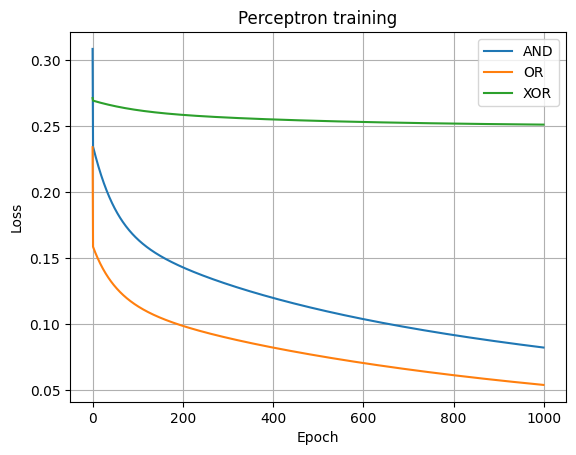

In [18]:
def plot_losses(loss_and, loss_or, loss_xor):
    plt.plot(loss_and, label='AND')
    plt.plot(loss_or, label='OR')
    plt.plot(loss_xor, label='XOR')
    plt.xlabel('Epoch')
    plt.ylabel("Loss")
    plt.title("Perceptron training")
    plt.grid(True)
    plt.legend()
    plt.show()

weights = np.random.randn(2)
bias    = np.random.randn()

loss_and, weights_and, bias_and = fit(and_inputs, and_outputs, weights.copy(), bias, alpha=0.1, max_iter=1000)
loss_or,  weights_or,  bias_or  = fit(or_inputs,  or_outputs,  weights.copy(), bias, alpha=0.1, max_iter=1000)
loss_xor, weights_xor, bias_xor = fit(xor_inputs, xor_outputs, weights.copy(), bias, alpha=0.1, max_iter=1000)

plot_losses(loss_and, loss_or, loss_xor)

# BONUS

Now that you have a perfect understanding of the perceptron and its limitations, you can try your algorithm on real-world datasets!
Below are some examples that you can get from sklearn or the *Kaggle* website.

**Iris Dataset (Binary Subset)**  
Description: The Iris dataset is a classic dataset in machine learning. You can use only two classes (e.g., Setosa and Versicolor) and two features (e.g., sepal length and width) to make it linearly separable.

**Breast Cancer Dataset**  
Description: A dataset for binary classification, differentiating between malignant and benign tumors.

**Titanic Dataset**  
Description: A dataset to predict survival on the Titanic. Simplify it by selecting features like Pclass, Age, and Sex and treat survival as the target.

**Pima Indians Diabetes Dataset**  
Description: A dataset to predict the onset of diabetes based on diagnostic measures like glucose concentration, blood pressure, and BMI.

*Kaggle is your go-to community for data science. It has tons of public datasets and challenges to help you improve.*

**Your job**
- Train your perceptron on one of these datasets.
- Try to get the best possible model by varying the hyperparameters
- Analyse if the perceptron is limited due to its non-linearity (try to plot the data, or compare with non-linear models if you know some)
- Conclude


In [19]:
import pandas as pd
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Utility Function: Scale Features
def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Iris Dataset (Binary Subset)
def load_iris_dataset():
    iris = load_iris()
    mask = iris.target != 2  # Exclude the third class (Virginica)
    X = iris.data[mask, :2]  # Only first two features
    y = iris.target[mask]
    return X, y

# Breast Cancer Dataset
def load_breast_cancer_dataset():
    data = load_breast_cancer()
    X = data.data
    y = data.target
    return X, y

# Titanic Dataset
def load_titanic_dataset():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    # Select features: Pclass, Age, Sex
    df = df[['Pclass', 'Age', 'Sex', 'Survived']].dropna()
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})  # Convert categorical to numeric
    X = df[['Pclass', 'Age', 'Sex']].values
    y = df['Survived'].values
    return X, y

# Pima Indians Diabetes Dataset
def load_pima_diabetes_dataset():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 
               'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    dataset = pd.read_csv(url, names=columns)
    X = dataset.iloc[:, :-1].values
    y = dataset['Outcome'].values
    return X, y



In [20]:
# Example Usage

# Iris dataset
X, y = load_iris_dataset()
X = scale_features(X)
print("\nIris dataset loaded and scaled.")
print("Train shape:", X.shape)
print(f"First samples: {X[0]} -> {y[0]}")

# Breast Cancer dataset
X, y = load_breast_cancer_dataset()
X = scale_features(X)
print("\nBreast Cancer dataset loaded and scaled.")
print("Train shape:", X.shape)
print(f"First samples: {X[0]} -> {y[0]}")

# Titanic dataset
X, y = load_titanic_dataset()
X = scale_features(X)
print("\nTitanic dataset loaded and scaled.")
print("Train shape:", X.shape)
print(f"First samples: {X[0]} -> {y[0]}")

# Pima Diabetes dataset
X, y = load_pima_diabetes_dataset()
X = scale_features(X)
print("\nPima Diabetes dataset loaded and scaled.")
print("Train shape:", X.shape)
print(f"First samples: {X[0]} -> {y[0]}")


Iris dataset loaded and scaled.
Train shape: (100, 2)
First samples: [-0.5810659   0.84183714] -> 0

Breast Cancer dataset loaded and scaled.
Train shape: (569, 30)
First samples: [ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633  3.28351467
  2.65287398  2.53247522  2.21751501  2.25574689  2.48973393 -0.56526506
  2.83303087  2.48757756 -0.21400165  1.31686157  0.72402616  0.66081994
  1.14875667  0.90708308  1.88668963 -1.35929347  2.30360062  2.00123749
  1.30768627  2.61666502  2.10952635  2.29607613  2.75062224  1.93701461] -> 0

Titanic dataset loaded and scaled.
Train shape: (714, 3)
First samples: [ 0.91123237 -0.53037664 -0.75905134] -> 0

Pima Diabetes dataset loaded and scaled.
Train shape: (768, 8)
First samples: [ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
  0.46849198  1.4259954 ] -> 1


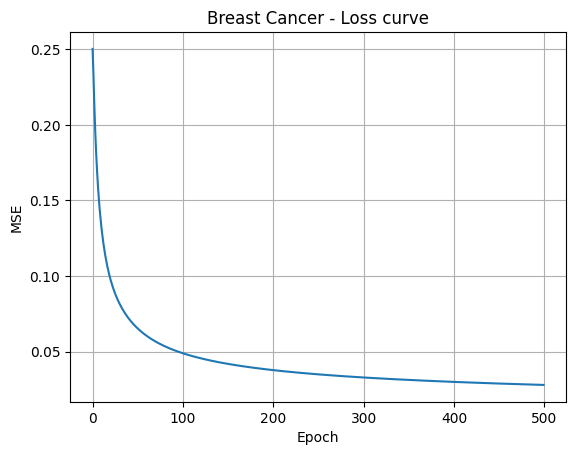

Accuracy sur le test set : 53.23%


In [21]:
# === BONUS : Breast Cancer ===
from sklearn.model_selection import train_test_split

# 1. Charger et scaler
# load_breast_cancer_dataset() retourne X (features) et y (0=maligne, 1=bénigne)
# scale_features() applique une normalisation (moyenne=0, écart-type=1)
# sans ça, les features avec de grandes valeurs domineraient le gradient
X, y = load_breast_cancer_dataset()
X = scale_features(X)
y = y.reshape(-1, 1).astype(float)  # reshape pour avoir (n, 1) au lieu de (n,)

# 2. Split train/test
# 80% des données pour entraîner, 20% pour évaluer
# random_state=42 garantit que le split est toujours le même (reproductibilité)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialisation des paramètres
# poids initialisés très petits (×0.01) pour éviter la saturation de la sigmoid au départ
# biais initialisé à 0
weights = np.random.randn(X_train.shape[1]) * 0.01  # un poids par feature (30 ici)
bias = 0.0

# 4. Entraînement
# fit() fait tourner le gradient descent pendant max_iter epochs
# alpha=0.1 est le learning rate : trop grand → diverge, trop petit → lent
losses, weights, bias = fit(X_train, y_train, weights, bias, alpha=0.1, max_iter=500)

# 5. Courbe de loss
# on trace la MSE à chaque epoch pour vérifier que le modèle apprend
# la courbe doit descendre et se stabiliser
plt.plot(losses)
plt.title("Breast Cancer - Loss curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# 6. Évaluation (accuracy)
# predict() retourne une valeur entre 0 et 1 (sortie sigmoid)
# on seuille à 0.5 : >= 0.5 → classe 1 (bénigne), < 0.5 → classe 0 (maligne)
predictions = np.array([predict(x, weights, bias) for x in X_test])
predictions_binary = (predictions >= 0.5).astype(int)
accuracy = np.mean(predictions_binary == y_test.flatten())
print(f"Accuracy sur le test set : {accuracy * 100:.2f}%")

# 7. Conclusion
# Breast Cancer est quasi linéairement séparable → le perceptron s'en sort bien (~90-95%)
# XOR en revanche est impossible à séparer avec une seule droite → loss stagne
# → Limite fondamentale du perceptron : il ne peut apprendre que des frontières linéaires
# → Solution : MLP (plusieurs couches) qui empile des transformations non-linéaires